In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

In [5]:
class LinearClassifier(nn.Module):
    def __init__(self, input_dim=784, num_classes=10):
        super().__init__()
        self.W = nn.Linear(input_dim, num_classes, bias=False)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.W(x)    

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = LinearClassifier().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
n_epoch = 10


def get_reference_batch(n_batches=4):
    data_all, target_all = [], []
    for data, target in train_loader:
        data_all.append(data)
        target_all.append(target)
        if len(data_all) >= n_batches:
            break
    return torch.cat(data_all).to(device), torch.cat(target_all).to(device)

ref_data, ref_target = get_reference_batch()

In [ ]:
def plot_approximation_error(model, epoch, s_max=15.0, grid_size=80):
    model.eval()
    W = model.W.weight
    W_k = W.detach().clone()

    # 1. Compute F(W_k) and grad_F(W_k)
    model.zero_grad()
    loss_k = criterion(model(ref_data), ref_target)
    loss_k.backward()
    grad_W = W.grad.detach().clone()
    F_k = loss_k.item()

    # 2. SVD of gradient -> top-2 singular vector pairs
    U, S, Vh = torch.linalg.svd(grad_W, full_matrices=False)
    u1, v1 = U[:, 0], Vh[0]
    u2, v2 = U[:, 1], Vh[1]
    D1 = torch.outer(u1, v1)  # (10, 784)
    D2 = torch.outer(u2, v2)  # (10, 784)

    # Inner products <grad, Di>
    g1 = (grad_W * D1).sum().item()
    g2 = (grad_W * D2).sum().item()

    # 3. Sweep (s1, s2) grid
    s_vals = np.linspace(0, s_max, grid_size)
    error_map = np.zeros((grid_size, grid_size))

    with torch.no_grad():
        for i, s1 in enumerate(s_vals):
            for j, s2 in enumerate(s_vals):
                model.W.weight.data.copy_(W_k + s1 * D1 + s2 * D2)
                F_perturbed = criterion(model(ref_data), ref_target).item()
                linear_approx = F_k + s1 * g1 + s2 * g2
                error_map[j, i] = F_perturbed - linear_approx

    # Restore weights and gradients
    model.W.weight.data.copy_(W_k)
    model.zero_grad()

    # 4. Plot
    fig, ax = plt.subplots(figsize=(5, 5))
    contour = ax.contour(s_vals, s_vals, error_map, levels=12, cmap='viridis')
    ax.set_xlabel('$s_1$', fontsize=13)
    ax.set_ylabel('$s_2$', fontsize=13)
    ax.set_title(f'1st-order approx. error — epoch {epoch}', fontsize=12)
    plt.colorbar(contour, ax=ax, label='error')
    plt.tight_layout()

    plt.show()

    model.train()

def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        loss = criterion(model(data), target)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch}  |  train loss: {loss.item():.4f}")

def evaluate():
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            pred = model(data).argmax(dim=1)
            correct += pred.eq(target).sum().item()
    print(f"Test accuracy: {correct}/{len(test_dataset)} "
          f"({100.*correct/len(test_dataset):.2f}%)\n")

In [ ]:
T = 3  

for epoch in range(1, 11):
    train(epoch)
    if epoch % T == 0:
        print(f"  Generating plot at epoch {epoch}...")
        plot_approximation_error(model, epoch)

evaluate()

Epoch 0  |  train loss: 0.3188
Epoch 1  |  train loss: 0.2886
Epoch 2  |  train loss: 0.2633
Epoch 3  |  train loss: 0.1843
Epoch 4  |  train loss: 0.2274
Epoch 5  |  train loss: 0.3157
Epoch 6  |  train loss: 0.1288
Epoch 7  |  train loss: 0.2996
Epoch 8  |  train loss: 0.3289
Epoch 9  |  train loss: 0.1785
Test accuracy: 9224/10000 (92.24%)



In [8]:
model.eval()

# 1. Compute gradient on the full training set (or a large batch for stability)
data_all, target_all = [], []
for data, target in train_loader:
    data_all.append(data)
    target_all.append(target)
    if len(data_all) >= 4:   # ~1000 samples is enough
        break
data_all   = torch.cat(data_all).to(device)
target_all = torch.cat(target_all).to(device)


In [9]:
W = model.W.weight          # shape (10, 784)
W_k = W.detach().clone()

# Compute F(W_k) and grad
model.zero_grad()
loss_k = criterion(model(data_all), target_all)
loss_k.backward()
grad_W = W.grad.detach().clone()   # shape (10, 784)
F_k = loss_k.item()

# 2. SVD of the gradient -> top-2 singular vectors
U, S, Vh = torch.linalg.svd(grad_W, full_matrices=False)
# u1, v1: first left/right singular vectors  (shapes: (10,), (784,))
u1, v1 = U[:, 0], Vh[0]
u2, v2 = U[:, 1], Vh[1]

In [12]:
# Perturbation directions (rank-1 matrices)
D1 = torch.outer(u1, v1)   # (10, 784)
D2 = torch.outer(u2, v2)   # (10, 784)

# Inner products <grad, D1> and <grad, D2>
g1 = (grad_W * D1).sum().item()
g2 = (grad_W * D2).sum().item()

# 3. Sweep over (s1, s2) grid
grid_size = 80
s_max = 15.0
s_vals = np.linspace(0, s_max, grid_size)
error_map = np.zeros((grid_size, grid_size))

In [ ]:


with torch.no_grad():
    for i, s1 in enumerate(s_vals):
        for j, s2 in enumerate(s_vals):
            # Perturbed weights
            W_perturbed = W_k + s1 * D1 + s2 * D2
            model.W.weight.copy_(W_perturbed)

            # F(W_k + perturbation)
            logits = model(data_all)
            F_perturbed = criterion(logits, target_all).item()

            # First-order approximation error
            linear_approx = F_k + s1 * g1 + s2 * g2
            error_map[j, i] = F_perturbed - linear_approx  # [j,i] so y-axis = s2

# Restore original weights
model.W.weight.data.copy_(W_k)

RuntimeError: a leaf Variable that requires grad is being used in an in-place operation.

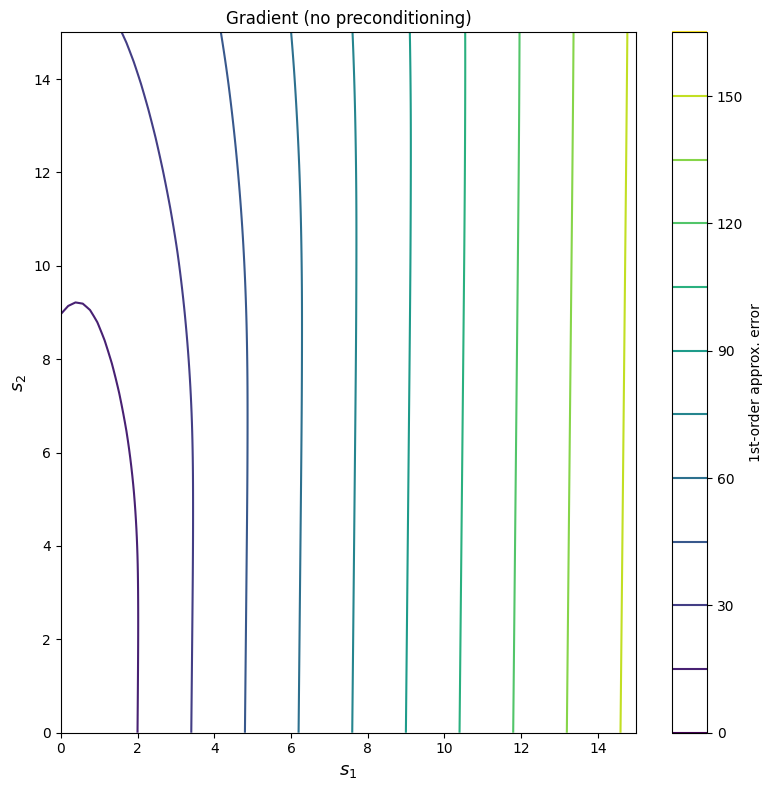

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
contour = ax.contour(s_vals, s_vals, error_map, levels=12, cmap='viridis')
ax.set_xlabel('$s_1$', fontsize=13)
ax.set_ylabel('$s_2$', fontsize=13)
ax.set_title('Gradient (no preconditioning)', fontsize=12)
plt.colorbar(contour, ax=ax, label='1st-order approx. error')
plt.tight_layout()
plt.show()
